In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "2" # second gpu
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"
    
from utils import *

# az.style.use("arviz-docgrid")
plt.rcParams['figure.dpi'] = 140

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv', index_col=0)
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [2]:
import jax
jax.config.update('jax_platform_name', 'gpu')

import jax.numpy as jnp
import jax.random as jr
from jax import lax
from jax import vmap
import optax

from jax.extend import backend
print(backend.get_backend().platform)

gpu


In [3]:
# Data Prepping

# copy r_table completely to keep backup
rdf = r_table.copy()
rdf['prev_target'] = rdf.groupby(['subj', 'sess', 'run'])['t_calib'].shift(1)
rdf['prev_resp']   = rdf.groupby(['subj', 'sess', 'run'])['resp'].shift(1)

# Replace NaN values in the first trial of each group with the current trial's value
rdf['prev_target'] = rdf['prev_target'].fillna(rdf['t_calib'])
rdf['prev_resp']   = rdf['prev_resp'].fillna(rdf['resp'])

# Modeling setup:
# - emissions : resp
# - inputs : t_calib, prev_target, prev_resp

# Training a global model - use all data combined
emissions = jnp.array(np.deg2rad(rdf['resp'].values.reshape(-1,120,1)))
inputs = jnp.array(np.deg2rad(rdf[['t_calib', 'prev_target', 'prev_resp']].values.reshape(-1,120,3)))
# emissions = jnp.array(np.deg2rad(rdf['resp'].values.reshape(-1,1)))
# inputs = jnp.array(np.deg2rad(rdf[['t_calib', 'prev_target', 'prev_resp']].values.reshape(-1,3)))

emissions.shape, inputs.shape

((288, 120, 1), (288, 120, 3))

## Regressor fiting

In [4]:
crossval_results = {}

for idx, (s_em, s_in) in tqdm(enumerate(zip(emissions.reshape(12, 4 * 6, 120, 1), inputs.reshape(12, 4 * 6, 120, 3)))):
    crossval_results[idx] = {}
    shuffle_idx = np.random.permutation(len(s_em))
    model = VonMisesTimeRegressor(input_dim=3, output_dim=1)
    ll_mean, ll = cross_validate_regressor(model=model, emissions=s_em[shuffle_idx], key=jr.PRNGKey(0), num_iters=5000, inputs=s_in[shuffle_idx], init="default")
    crossval_results[idx][1] = ll

12it [00:41,  3.48s/it]


In [5]:
with open('./caches/one_state_crossval_result.pkl', 'wb') as f:
    pickle.dump(crossval_results, f)

Fitting: 100%|██████████| 5000/5000 [00:01<00:00, 4550.67it/s]


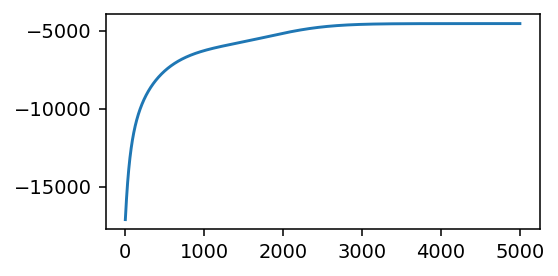

In [6]:
# model = VonMisesRegressor(input_dim=3, output_dim=1)
model = VonMisesTimeRegressor(input_dim=3, output_dim=1)
params, props = model.initialize(key=jr.PRNGKey(0), method="prior")
fit_params, lls = model.fit_em(params, props, emissions[:24], num_iters=5000, inputs=inputs[:24], learning_rate=1e-3)
plt.figure(figsize=(4,2))
plt.plot(lls)

In [7]:
# log_probs = model.marginal_log_prob(fit_params, emissions[:28], inputs=inputs[:28])
# print("Log probabilities:", log_probs)

In [8]:
# final_ll = lls[-1]
# n_obs = inputs.shape[0]
# k_params = model.num_params()

# # Calculate AIC and BIC:
# aic_value = VonMisesRegressor.aic(final_ll, k_params)
# bic_value = VonMisesRegressor.bic(final_ll, k_params, n_obs)
# print(f"AIC: {aic_value}, BIC: {bic_value}")


In [9]:
# For computing log probabilities on new/validation data:
#   x_val: jnp.array of shape (n_val, 3)
#   y_val: jnp.array of shape (n_val, 1)
# log_probs = model.marginal_log_prob(fit_params, emissions, inputs=inputs)
# print("Log probabilities:", log_probs)
# log_probs = model.marginal_log_prob(fit_params, emissions[:1], inputs=inputs[:1])
# print("Log probabilities:", log_probs)